In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
# Load CIFAR-10 Dataset
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training Images :", x_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images :", x_test.shape)
print("Testing Labels :", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4877s 29us/step
Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 1)
Testing Images : (10000, 32, 32, 3)
Testing Labels : (10000, 1)


In [3]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

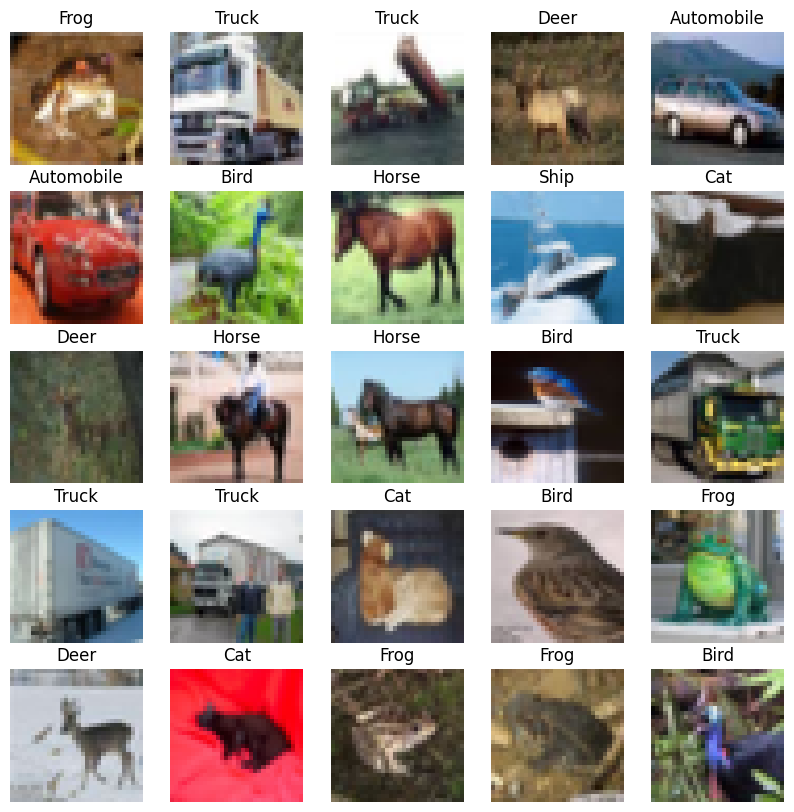

In [4]:
plt.figure(figsize=(10,10))

for i in range(25):

    plt.subplot(5,5,i+1)

    plt.imshow(x_train[i])

    plt.title(class_names[y_train[i][0]])

    plt.axis("off")

plt.show()

In [5]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Normalization Completed")

Normalization Completed


In [6]:
data_augmentation = keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1)

])

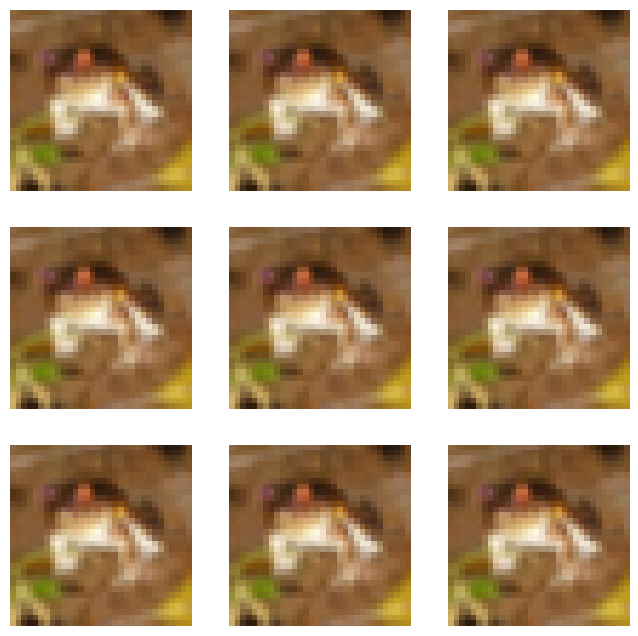

In [9]:
plt.figure(figsize=(8,8))

for images in data_augmentation(x_train[:1]):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images)

        plt.axis("off")

plt.show()

In [10]:
model = Sequential([

    data_augmentation,

    layers.Conv2D(32, (3,3), activation="relu", input_shape=(32,32,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(10, activation="softmax")

])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (1, 32, 32, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (1, 30, 30, 32)        │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (1, 15, 15, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 13, 13, 64)        │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (1, 6, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (1, 4, 4, 128)         │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (1, 2, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (1, 512)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 128)               │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 10)                │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [22]:
history = model.fit(

    x_train,

    y_train,

    epochs=15,

    batch_size=64,

    validation_split=0.2

)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7454 - loss: 0.7373 - val_accuracy: 0.7487 - val_loss: 0.7783
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7454 - loss: 0.7426 - val_accuracy: 0.7321 - val_loss: 0.8304
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7472 - loss: 0.7340 - val_accuracy: 0.7307 - val_loss: 0.7999
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7470 - loss: 0.7354 - val_accuracy: 0.7378 - val_loss: 0.7930
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.7443 - loss: 0.7382 - val_accuracy: 0.7437 - val_loss: 0.7843
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7471 - loss: 0.7346 - val_accuracy: 0.7507 - val_loss: 0.7651
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7476 - loss: 0.7283 - val_accuracy: 0.7366 - val_loss: 0.7957
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7512 - loss: 0.7281 - val_accuracy:

In [23]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print()

print("Test Accuracy :", test_accuracy)

print("Test Loss :", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7451 - loss: 0.7883

Test Accuracy : 0.7451000213623047
Test Loss : 0.7882823348045349


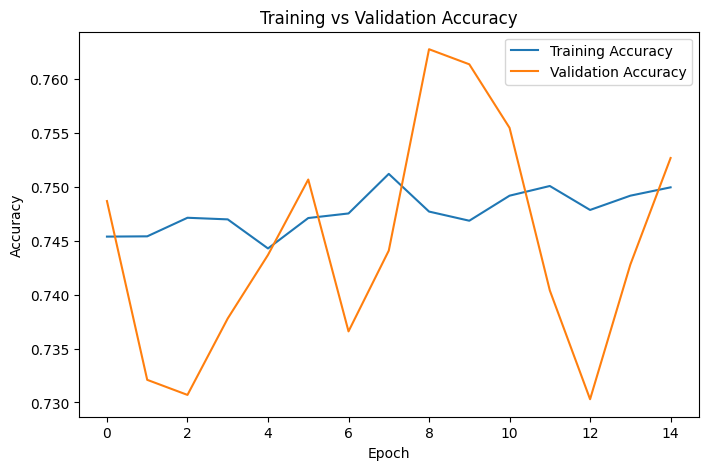

In [24]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

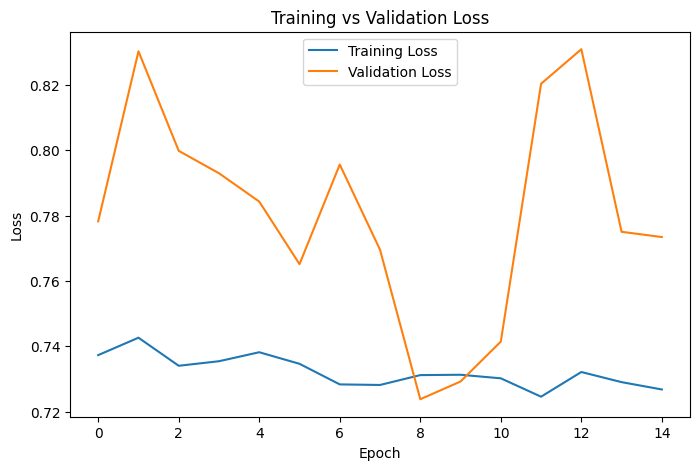

In [25]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step


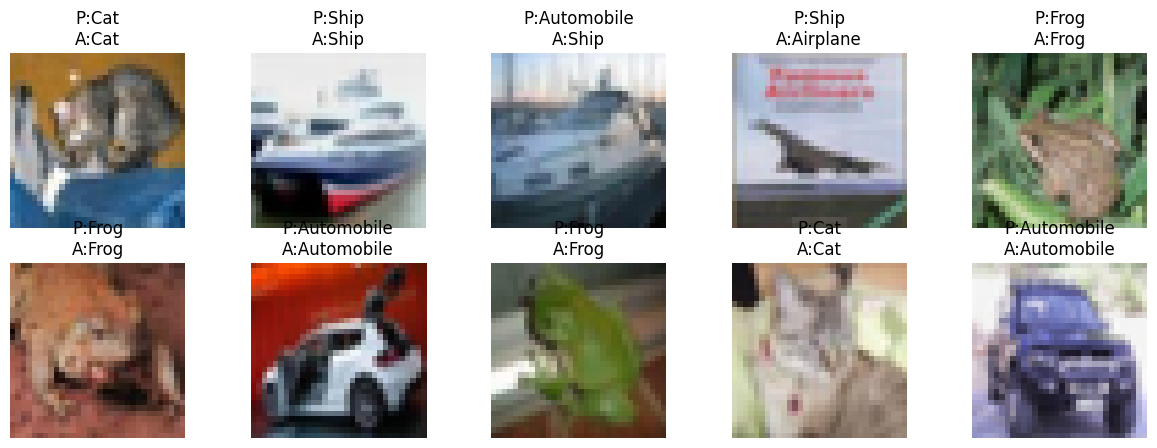

In [26]:
predictions = model.predict(x_test[:10])

plt.figure(figsize=(15,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(x_test[i])

    predicted_class = np.argmax(predictions[i])

    actual_class = y_test[i][0]

    plt.title(f"P:{class_names[predicted_class]}\nA:{class_names[actual_class]}")

    plt.axis("off")

plt.show()

In [28]:
model.save("image_classifier.h5")


In [29]:
from google.colab import files

files.download("image_classifier.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>